<a href="https://colab.research.google.com/github/kebalriv25-max/-Proyecto_RappiPlus_Analisis_de_datos_detallado/blob/main/Proyecto_Datos_RappiPlus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto consisitió en evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajaron con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transformaron datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarización de la estructura de los datasets del negocio antes de analizarlos.

**Secuencia Seguida:**

- Importación de librerías necesarias
- Carga de archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda de DataFrames en:
  - `orders`, `catalog`, `marketing`
- Exploración de cada dataset.

---

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# cargar archivos
orders1 = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog1 = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing1 = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

orders = orders1.copy()
catalog = catalog1.copy()
marketing = marketing1.copy()


In [ ]:
# explorar datasets
print("DATOS ORDERS")
display(orders.head())
orders.info()
print()
print("DATOS DISPLAY")
display(catalog.head())
catalog.info()
print()
print("DATOS MARKETING")
display(marketing.head())
marketing.info()

DATOS ORDERS


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB

DATOS DISPLAY


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes

DATOS MARKETING


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
# Validar y convertir fechas al formato correcto
print("=========================================================")
print("================Validar y Convertir Fechas===============")
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors = 'coerce')
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors = 'coerce')
print(f"Cantidad de nulos en `fecha_hora_pedido`:\n {orders['fecha_hora_pedido'].isnull().sum()}")
print(f"Cantidad de nulos en `fecha`:\n {marketing['fecha'].isnull().sum()}")
print("=========================================================")

# Revisar variables numéricas (sin negativos o ceros inválidos)
numericas_orders = ['cantidad','precio_unitario','monto_descuento','monto_total']
numericas_catalog = ['costo_unitario']
numericas_marketing = ['gasto']

print("================Revisar Variables Numericas==============")
print("---dataset orders---")
orders[numericas_orders] = orders[numericas_orders].abs()
print("Cantidad de nulos en columnas numericas:\n", orders[numericas_orders].isnull().sum())
print("Cantidad de negativos en columnas numericas:\n", (orders[numericas_orders]< 0).sum())
print(f'Antes de eliminar nulos: {len(orders)} filas')
orders = orders.dropna(subset = ['cantidad'])
print(f'Después de eliminar nulos: {len(orders)} filas')

print("\n---dataset catalog---")
print("Cantidad de nulos en columnas numericas:\n", catalog[numericas_catalog].isnull().sum())
print("Cantidad de negativos en columnas numericas:\n", (catalog[numericas_catalog]<0).sum())
print(f'Antes de eliminar nulos: {len(catalog)} filas')
catalog = catalog.dropna(subset=numericas_catalog)
print(f'Después de eliminar nulos: {len(catalog)} filas')

print("\n---dataset marketing---")
print("Cantidad de nulos en columnas numericas:\n", marketing[numericas_marketing].isnull().sum())
print("Cantidad de negativos en columnas numericas:\n", (marketing[numericas_marketing]<0).sum())
print(f'Antes de eliminar nulos: {len(marketing)} filas')
marketing = marketing.dropna(subset=numericas_marketing)
print(f'Después de eliminar nulos: {len(marketing)} filas')
print("=========================================================")

# Verificar consistencia de montos
orders['monto_total'] = (orders['cantidad'] * orders['precio_unitario']) - orders['monto_descuento']

# Eliminar duplicados
print("===================Eliminar Duplicados===================")
print("---dataset orders---")
print(f'Filas totales: {len(orders)}')
print(f'Duplicados: {orders.duplicated().sum()}')
orders = orders.drop_duplicates()
print(f'Después de eliminar duplicados: {len(orders)} filas')
print("---dataset catalog---")
print(f'Filas totales: {len(catalog)}')
print(f'Duplicados: {catalog.duplicated().sum()}')
catalog = catalog.drop_duplicates()
print(f'Después de eliminar duplicados: {len(catalog)} filas')
print("---dataset marketing---")
print(f'Filas totales: {len(marketing)}')
print(f'Duplicados: {marketing.duplicated().sum()}')
marketing = marketing.drop_duplicates()
print(f'Después de eliminar duplicados: {len(marketing)} filas')
print("=========================================================")

# Revisar variables categóricas
print("==============Revisar Variables Categoricas==============")
print("---Orders---")
categoricas_orders = ['pais','dispositivo','fuente_referencia','categoria_producto']
for col in categoricas_orders:
    orders[col] = orders[col].str.lower().str.strip().fillna('Desconocido')
    unico = orders[col].unique()
    cantidad = orders[col].isnull().sum()
    print(f"Columna: {col} | cantidad de nulos: {cantidad}")
    print(f"{unico}\n")

print("---Catalog---")
categoricas_catalog = ['categoria_producto','proveedor']
for col in categoricas_catalog:
    catalog[col] = catalog[col].str.lower().str.strip()
    unico = catalog[col].unique()
    cantidad = catalog[col].isnull().sum()
    print(f"Columna: {col} | cantidad de nulos: {cantidad}")
    print(f"{unico}\n")

print("---Marketing---")
categoricas_marketing = ['pais','id_campaña','canal']
for col in categoricas_marketing:
    marketing[col] = marketing[col].str.lower().str.strip()
    marketing['canal'] = marketing['canal'].fillna(marketing['id_campaña'].str.split('_').str[0])
    unico = marketing[col].unique()
    cantidad = marketing[col].isnull().sum()
    print(f"Columna: {col} | cantidad de nulos: {cantidad}")
    print(f"{unico}\n")

================Validar y Convertir Fechas===============
Cantidad de nulos en `fecha_hora_pedido`:
 0
Cantidad de nulos en `fecha`:
 0
================Revisar Variables Numericas==============
---dataset orders---
Cantidad de nulos en columnas numericas:
 cantidad           50
precio_unitario    50
monto_descuento    50
monto_total         0
dtype: int64
Cantidad de negativos en columnas numericas:
 cantidad           0
precio_unitario    0
monto_descuento    0
monto_total        0
dtype: int64
Antes de eliminar nulos: 25100 filas
Después de eliminar nulos: 25050 filas

---dataset catalog---
Cantidad de nulos en columnas numericas:
 costo_unitario    0
dtype: int64
Cantidad de negativos en columnas numericas:
 costo_unitario    0
dtype: int64
Antes de eliminar nulos: 7 filas
Después de eliminar nulos: 7 filas

---dataset marketing---
Cantidad de nulos en columnas numericas:
 gasto    0
dtype: int64
Cantidad de negativos en columnas numericas:
 gasto    0
dtype: int64
Antes de eliminar

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportaron los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usaron los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
# Unimos orders con catalog para obtener costo_unitario por producto
orders_catalog = orders.merge(catalog[['nombre_producto', 'costo_unitario']],
                               on='nombre_producto', how='left')

# Calcular costo total por línea de pedido
orders_catalog['costo_linea'] = orders_catalog['cantidad'] * orders_catalog['costo_unitario']

# KPIs
revenue_total   = orders_catalog['monto_total'].sum()
costo_total     = orders_catalog['costo_linea'].sum()
marketing_total = marketing['gasto'].sum()
profit_total    = revenue_total - costo_total - marketing_total
margen_profit   = (profit_total / revenue_total) * 100

print('=' * 45)
print('RENTABILIDAD DEL NEGOCIO')
print('=' * 45)
print(f'Revenue total:          ${revenue_total:>15,.2f}')
print(f'Costo total productos:  ${costo_total:>15,.2f}')
print(f'Inversión en marketing: ${marketing_total:>15,.2f}')
print(f'Profit (ganancia neta): ${profit_total:>15,.2f}')
print(f'Margen de profit:       {margen_profit:>15.2f}%')
print('=' * 45)
rentable = 'SÍ es rentable' if profit_total > 0 else 'NO es rentable'
print(f'¿El negocio es rentable? → {rentable}')

RENTABILIDAD DEL NEGOCIO
Revenue total:          $  51,968,129.67
Costo total productos:  $  43,124,119.61
Inversión en marketing: $   2,871,843.53
Profit (ganancia neta): $   5,972,166.53
Margen de profit:                 11.49%
¿El negocio es rentable? → SÍ es rentable


In [ ]:
# Ticket promedio por orden
ticket_promedio = orders_catalog['monto_total'].mean()

# Cantidad promedio de productos por orden
cantidad_promedio = orders_catalog['cantidad'].mean()

# Producto más vendido (por unidades vendidas)
producto_mas_vendido = (orders_catalog.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False))

# Marketing por canal
mkt_por_canal = (marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False).reset_index())

print('=' * 45)
print('COMPORTAMIENTO DE VENTAS')
print('=' * 45)
print(f'Ticket promedio por orden:          ${ticket_promedio:,.2f}')
print(f'Cantidad promedio por orden:        {cantidad_promedio:.2f} unidades')
print()
print('Top 5 productos más vendidos (unidades):')
display(producto_mas_vendido.head(5).reset_index().rename(columns={'cantidad':'unidades_vendidas'}))

print('\nGasto en marketing por canal:')
mkt_por_canal['porcentaje'] = (mkt_por_canal['gasto'] / mkt_por_canal['gasto'].sum() * 100).round(2)
display(mkt_por_canal)

COMPORTAMIENTO DE VENTAS
Ticket promedio por orden:          $2,082.89
Cantidad promedio por orden:        7.12 unidades

Top 5 productos más vendidos (unidades):


,nombre_producto,unidades_vendidas
0,Laptop-Gaming-16GB,144198.0
1,Vacuum-Pro-Black,6284.0
2,Blender-XL-Red,6279.0
3,Jacket-Winter-M,6256.0
4,Sneakers-Urban-42,6172.0



Gasto en marketing por canal:


,canal,gasto,porcentaje
0,social,976818.37,34.01
1,organic,972650.96,33.87
2,paid_search,863088.21,30.05
3,paid,59285.99,2.06


## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecutó la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
from sqlalchemy import create_engine

# ======================
# Conexión
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [ ]:
# Vista general de los eventos disponibles
query_eventos_unicos = '''
SELECT nombre_evento, COUNT(*) AS total_eventos
FROM events
GROUP BY nombre_evento
ORDER BY total_eventos DESC;
'''
eventos_unicos = pd.read_sql(query_eventos_unicos, con=engine)
print('Eventos disponibles en la tabla:')
display(eventos_unicos)

Eventos disponibles en la tabla:


,nombre_evento,total_eventos
0,first_visit,29957
1,add_to_cart,24157
2,select_item,23887
3,begin_checkout,17971
4,add_payment_info,12018
5,purchase,12010


In [ ]:
# PARTE 1: Totales del funnel
# ======================
query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY nombre_evento
ORDER BY
    CASE nombre_evento
        WHEN 'first_visit'       THEN 1
        WHEN 'product_view'      THEN 2
        WHEN 'add_to_cart'       THEN 3
        WHEN 'begin_checkout'    THEN 4
        WHEN 'purchase'          THEN 5
        ELSE 6
    END;
'''

totals = pd.read_sql(query_totals, con=engine)
print('Usuarios únicos por etapa del funnel:')
display(totals)

Usuarios únicos por etapa del funnel:


,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,begin_checkout,7208
3,purchase,6240
4,add_payment_info,6250
5,select_item,7582


In [ ]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel AS (
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos,
        CASE nombre_evento
            WHEN 'first_visit'    THEN 1
            WHEN 'product_view'   THEN 2
            WHEN 'add_to_cart'    THEN 3
            WHEN 'begin_checkout' THEN 4
            WHEN 'purchase'       THEN 5
            ELSE 6
        END AS orden_etapa
    FROM events
    GROUP BY nombre_evento
),
funnel_ordenado AS (
    SELECT *
    FROM funnel
    ORDER BY orden_etapa
)
SELECT
    nombre_evento,
    usuarios_unicos,
    LAG(usuarios_unicos) OVER (ORDER BY orden_etapa) AS usuarios_etapa_anterior,
    ROUND(
        100.0 * usuarios_unicos
        / NULLIF(LAG(usuarios_unicos) OVER (ORDER BY orden_etapa), 0),
    2) AS tasa_conversion_paso_pct,
    ROUND(
        100.0 * usuarios_unicos
        / FIRST_VALUE(usuarios_unicos) OVER (ORDER BY orden_etapa),
    2) AS tasa_conversion_total_pct
FROM funnel_ordenado
ORDER BY orden_etapa;
'''

conversion = pd.read_sql(query_conversion, con=engine)
print('Tasas de conversión del funnel:')
display(conversion)

# Identificar el mayor drop-off
conversion_sin_nulos = conversion.dropna(subset=['tasa_conversion_paso_pct'])
idx_mayor_drop = conversion_sin_nulos['tasa_conversion_paso_pct'].idxmin()
etapa_drop = conversion_sin_nulos.loc[idx_mayor_drop, 'nombre_evento']
tasa_drop  = conversion_sin_nulos.loc[idx_mayor_drop, 'tasa_conversion_paso_pct']
print(f'\nMayor punto de abandono (drop-off): etapa "{etapa_drop}" con solo {tasa_drop}% de conversión desde el paso anterior.')

# Tasa de conversión final
tasa_final = conversion[conversion['nombre_evento'] == 'purchase']['tasa_conversion_total_pct'].values
if len(tasa_final) > 0:
    print(f'Tasa de conversión final (first_visit → purchase): {tasa_final[0]}%')

Tasas de conversión del funnel:


,nombre_evento,usuarios_unicos,usuarios_etapa_anterior,tasa_conversion_paso_pct,tasa_conversion_total_pct
0,first_visit,7796,NaN,NaN,100.00
1,add_to_cart,7634,7796.0,97.92,97.92
2,begin_checkout,7208,7634.0,94.42,92.46
3,purchase,6240,7208.0,86.57,80.04
4,add_payment_info,6250,6240.0,100.16,80.17
5,select_item,7582,6250.0,121.31,97.26



Mayor punto de abandono (drop-off): etapa "purchase" con solo 86.57% de conversión desde el paso anterior.
Tasa de conversión final (first_visit → purchase): 80.04%


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity
LIMIT 100;
'''

user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohorte_base AS (
    -- Identificar la cohorte (mes de registro) y contar usuarios por cohorte
    SELECT
        id_usuario,
        TO_CHAR(CAST(fecha_registro AS DATE), 'YYYY-MM') AS cohorte_mes,
        CAST(fecha_registro AS DATE) AS fecha_registro
    FROM users
),
actividad_semanal AS (
    -- Unir usuarios con su actividad semanal
    SELECT
        c.id_usuario,
        c.cohorte_mes,
        a.dias_despues_registro,
        a.activo
    FROM cohorte_base c
    LEFT JOIN user_activity a ON c.id_usuario = a.id_usuario
),
retencion_semanal AS (
    SELECT
        cohorte_mes,
        COUNT(DISTINCT id_usuario) AS usuarios_cohorte,
        -- Semana 1: días 1 a 7
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 1 AND 7 AND activo = 1
            THEN id_usuario END) AS retenido_w1,
        -- Semana 2: días 8 a 14
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 8 AND 14 AND activo = 1
            THEN id_usuario END) AS retenido_w2,
        -- Semana 3: días 15 a 21
        COUNT(DISTINCT CASE
            WHEN dias_despues_registro BETWEEN 15 AND 21 AND activo = 1
            THEN id_usuario END) AS retenido_w3
    FROM actividad_semanal
    GROUP BY cohorte_mes
)
SELECT
    cohorte_mes,
    usuarios_cohorte,
    retenido_w1,
    retenido_w2,
    retenido_w3,
    ROUND(100.0 * retenido_w1 / NULLIF(usuarios_cohorte, 0), 2) AS semana_1,
    ROUND(100.0 * retenido_w2 / NULLIF(usuarios_cohorte, 0), 2) AS semana_2,
    ROUND(100.0 * retenido_w3 / NULLIF(usuarios_cohorte, 0), 2) AS semana_3
FROM retencion_semanal
ORDER BY cohorte_mes;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
print('Retención semanal por cohorte de registro:')
display(cohorte_final)

# Insight de retención
print('\nRetención promedio por semana:')
print(f'  Semana 1: {cohorte_final["semana_1"].mean():.2f}%')
print(f'  Semana 2: {cohorte_final["semana_2"].mean():.2f}%')
print(f'  Semana 3: {cohorte_final["semana_3"].mean():.2f}%')

Retención semanal por cohorte de registro:


,cohorte_mes,usuarios_cohorte,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02,1444,611,609,635,42.31,42.17,43.98
2,2025-03,1636,677,705,690,41.38,43.09,42.18
3,2025-04,1606,680,697,663,42.34,43.40,41.28
4,2025-05,1687,695,676,706,41.20,40.07,41.85



Retención promedio por semana:
  Semana 1: 42.01%
  Semana 2: 41.96%
  Semana 3: 41.92%


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No hay diferencia en la conversion entre el grupo control y el grupo de tratamiento al aplicarse la modificación en la UI del checkout.
   - **H₁ (Hipótesis alternativa):** Si hay diferencia en la conversion entre el grupo control y el grupo de tratamiento al aplicarse la modificación en la UI del checkout.
   
**Test estadístico:** Prueba Z-test  
**Nivel de significancia alpha:** 0.05

In [ ]:
experiment = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

print('Shape:', experiment.shape)
print('\nValores nulos:')
print(experiment.isnull().sum())
print('\nDistribución por variante:')
print(experiment['variante'].value_counts())
display(experiment.head(3))


Shape: (10000, 7)

Valores nulos:
id_usuario         0
variante           0
convirtio          0
dispositivo        0
pais               0
duracion_sesion    0
timestamp          0
dtype: int64

Distribución por variante:
tratamiento    5035
control        4965
Name: variante, dtype: int64


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18


In [ ]:
# Separar grupos
control    = experiment[experiment['variante'] == 'control']['convirtio']
tratamiento = experiment[experiment['variante'] == 'tratamiento']['convirtio']

# Tasas de conversión
cr_control    = control.mean()
cr_tratamiento = tratamiento.mean()
diferencia    = cr_tratamiento - cr_control

print('=' * 50)
print('RESULTADOS DEL EXPERIMENTO A/B')
print('=' * 50)
print(f'Grupo Control    → n={len(control)}  | CR = {cr_control:.4f} ({cr_control*100:.2f}%)')
print(f'Grupo Tratamiento → n={len(tratamiento)} | CR = {cr_tratamiento:.4f} ({cr_tratamiento*100:.2f}%)')

RESULTADOS DEL EXPERIMENTO A/B
Grupo Control    → n=4965  | CR = 0.1569 (15.69%)
Grupo Tratamiento → n=5035 | CR = 0.1629 (16.29%)


In [ ]:
# Test Z de proporciones
alpha = 0.05

numer_convers  = np.array([tratamiento.sum(), control.sum()])
total_convers   = np.array([len(tratamiento), len(control)])

z_stat, p_value = proportions_ztest(numer_convers, total_convers)

print('=' * 50)
print('TEST ESTADÍSTICO: Z-test de proporciones')
print('=' * 50)
print(f'Estadístico Z:   {z_stat:.4f}')
print(f'P-valor:         {p_value:.4f}')
print(f'Nivel de alpha:  {alpha}')
print()

if p_value < alpha:
    print('RESULTADO: Se RECHAZA H₀.')
    print(f'   El p-valor ({p_value:.4f}) < alpha ({alpha}), por lo tanto la diferencia')
    print('   en tasas de conversión ES estadísticamente significativa.')
    print()
    if diferencia > 0:
        print('RECOMENDACIÓN: La nueva UI del checkout mejora la tasa de conversión.')
        print('   Se recomienda implementar el cambio en producción.')
    else:
        print('RECOMENDACIÓN: La nueva UI del checkout REDUCE la tasa de conversión.')
        print('   NO se recomienda implementar el cambio.')
else:
    print('RESULTADO: NO se rechaza H₀.')
    print(f'   El p-valor ({p_value:.4f}) >= alpha ({alpha}), por lo tanto la diferencia')
    print('   observada NO es estadísticamente significativa.')
    print()
    print('RECOMENDACIÓN: No hay evidencia suficiente para afirmar que la nueva UI')
    print('   genera impacto en la conversión. Se sugiere continuar el experimento')
    print('   o rediseñar la intervención.')

TEST ESTADÍSTICO: Z-test de proporciones
Estadístico Z:   0.8133
P-valor:         0.4161
Nivel de alpha:  0.05

RESULTADO: NO se rechaza H₀.
   El p-valor (0.4161) >= alpha (0.05), por lo tanto la diferencia
   observada NO es estadísticamente significativa.

RECOMENDACIÓN: No hay evidencia suficiente para afirmar que la nueva UI
   genera impacto en la conversión. Se sugiere continuar el experimento
   o rediseñar la intervención.


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Resumen Ejecutivo

**KPIs principales:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Margen profit

**Visualizaciones propuestas:**
- Tarjetas KPI
- Gráfico de líneas: evolución mensual de revenue
- Gráfico de anillo: distribución del gasto en marketing por canal
- Gráfico de barras: revenue y profit por producto o categoría

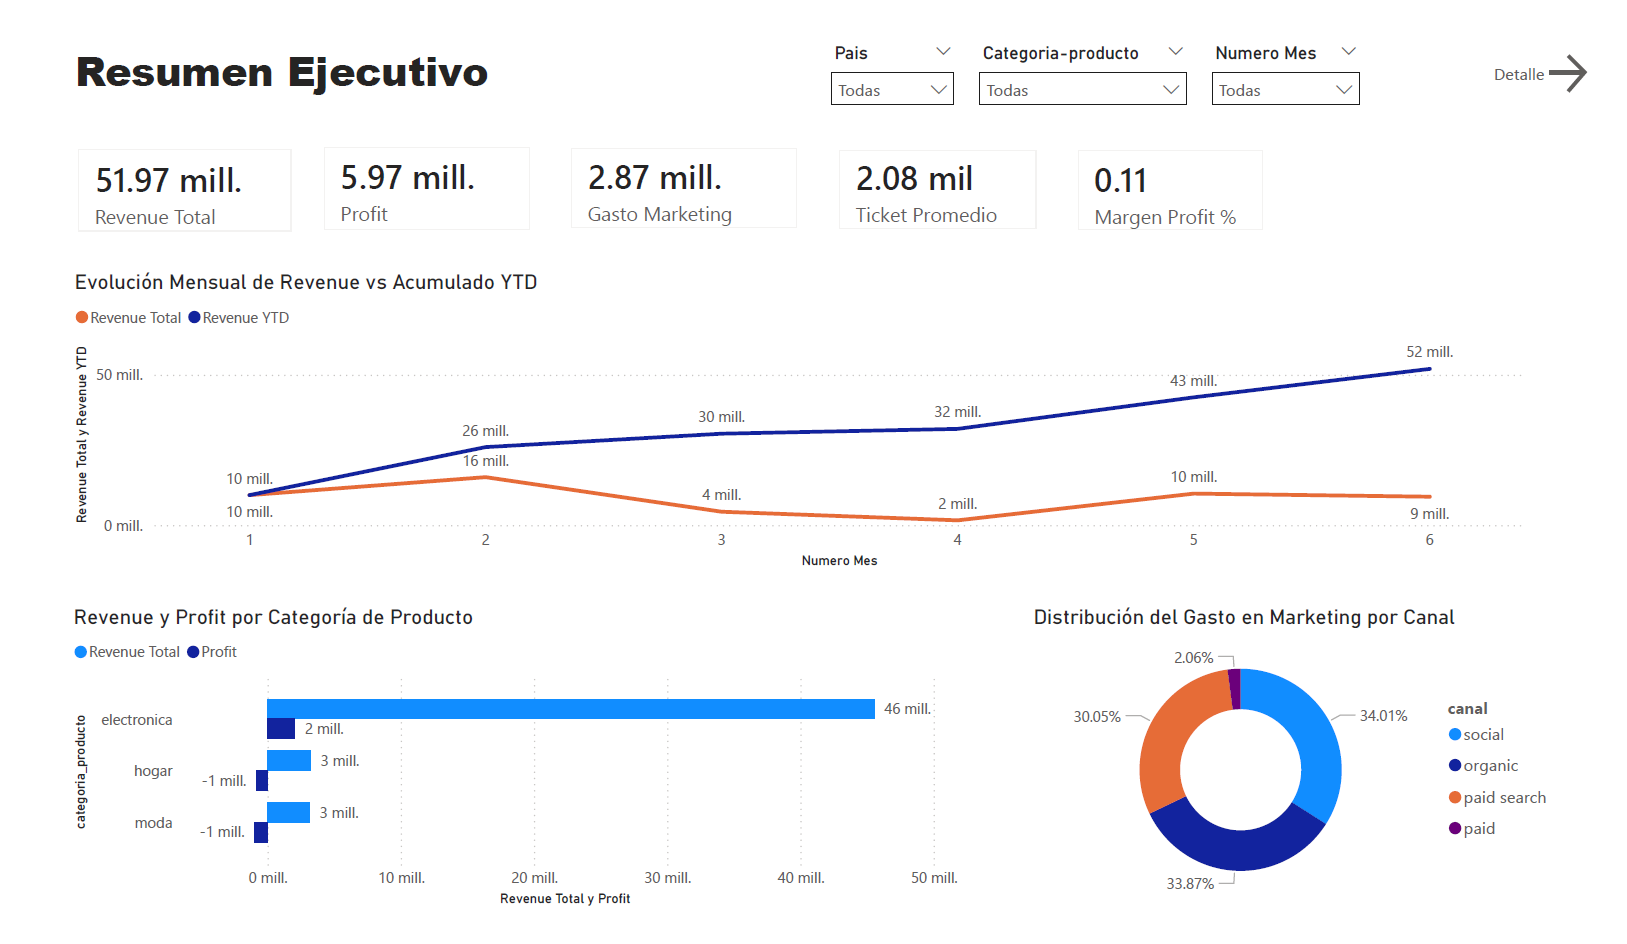





---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones propuestas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

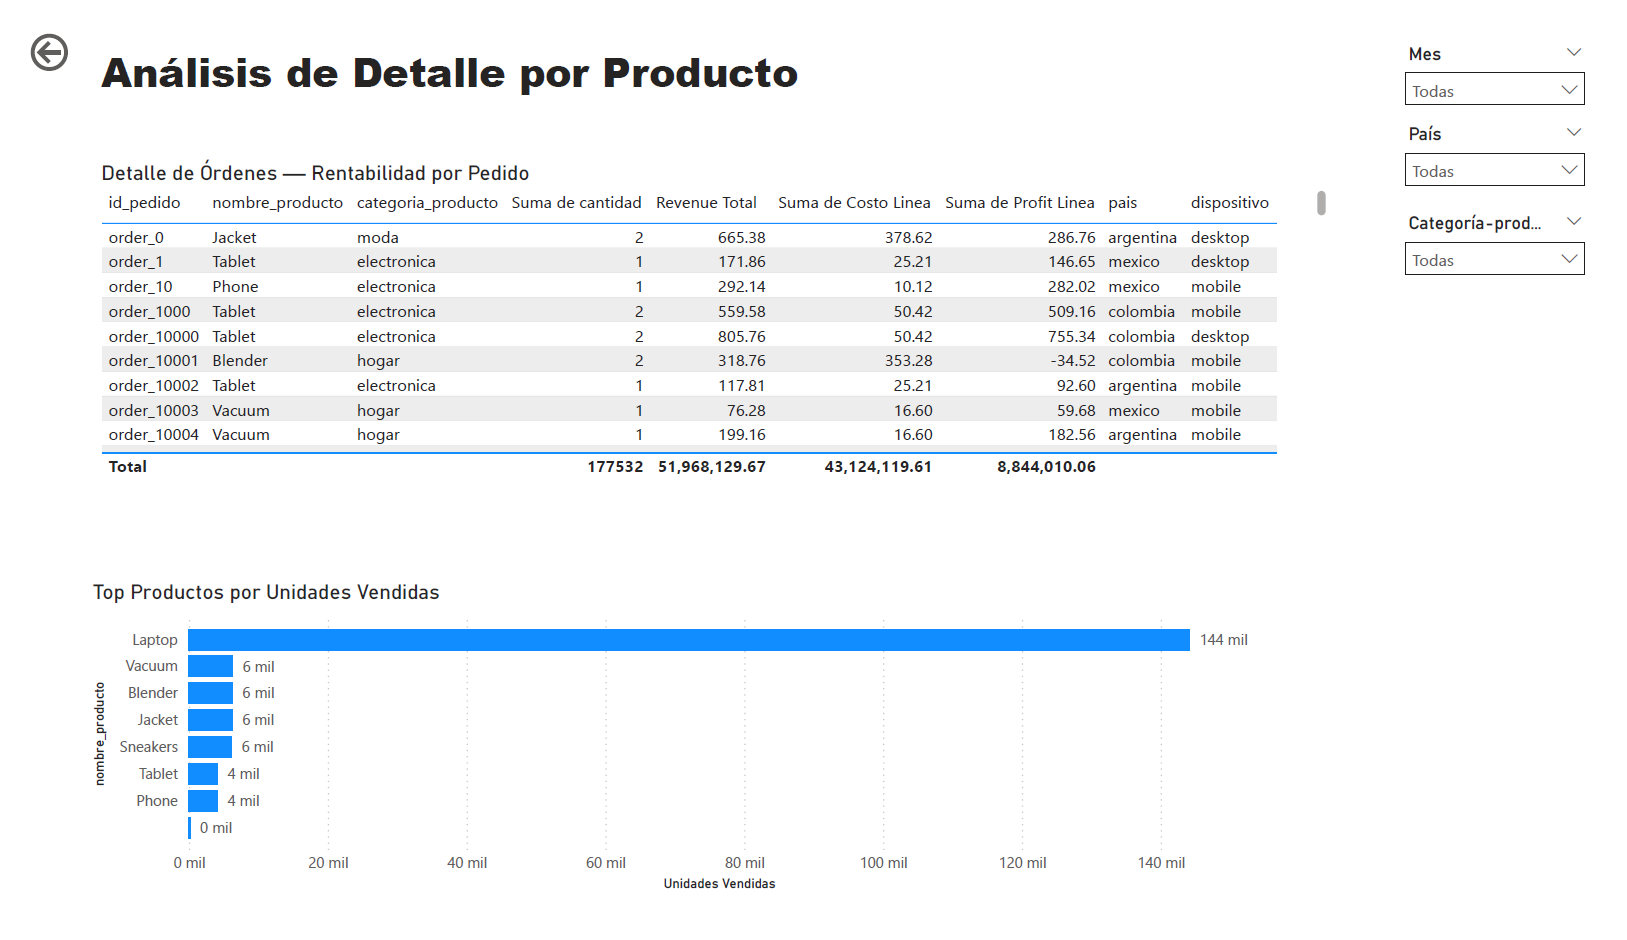

---